# Chapter 6: The Hodge Theorem

**Source Span.** `Foundations of Differentiable Manifolds and Lie Groups.pdf` printed pages `220-259`, covering the Laplace-Beltrami operator, the Hodge theorem, Fourier/Sobolev-style calculus estimates, elliptic operators, reduction to the periodic case, ellipticity of the Laplace-Beltrami operator, and exercises before the bibliography.

**Chapter Goal.** See Hodge theory as the meeting point of geometry, analysis, and cohomology. The Hodge star gives an inner product on forms. The Laplace-Beltrami operator combines `d` and its adjoint. Harmonic forms represent de Rham classes. Elliptic estimates and periodic/Fourier reductions explain why the analytic operator has finite-dimensional, smooth, cohomologically meaningful solutions.

This notebook uses compact executable models: Hodge-star signs in dimension two, Fourier eigenmodes of the scalar Laplacian, a finite-dimensional Hodge decomposition model, Sobolev-style coefficient decay, elliptic symbol positivity, and a proof dependency graph. These are original teaching models rather than copied source material.


In [1]:
from pathlib import Path
import json, math, sys
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp
import plotly.graph_objects as go
BOOK_ROOT=None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate/'AGENTS.md').exists() and (candidate/'source_map.json').exists(): BOOK_ROOT=candidate; break
if BOOK_ROOT is None: raise RuntimeError('book root not found')
if str(BOOK_ROOT) not in sys.path: sys.path.insert(0,str(BOOK_ROOT))
from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib, save_plotly_html
UNIT_KEY='chapter-06-the-hodge-theorem'
ARTIFACT_ROOT=chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES,HTML,CHECKS,TABLES=(ARTIFACT_ROOT/name for name in ['figures','html','checks','tables'])
TRACKED_ARTIFACTS=[]
print(f'Book root: {BOOK_ROOT}')


Book root: D:\Geometry\Foundations-of-Differentiable-Manifolds-and-Lie-Groups


## Visual Storyboard

1. **Hodge-star sign table.** The action of `*` on basis forms in an oriented two-dimensional Euclidean model is recorded, including `*^2` signs by degree.
2. **Laplace eigenmodes.** Fourier modes on the circle are plotted with their eigenvalues, showing why periodic analysis is natural in the proof.
3. **Finite Hodge decomposition.** A symmetric positive semidefinite matrix model decomposes vectors into harmonic and nonharmonic components.
4. **Sobolev coefficient decay and elliptic symbol.** Fourier coefficient weights and the Laplace symbol `|xi|^2` make elliptic control inspectable.
5. **Proof dependency graph.** Hodge star, adjoint, Laplacian, elliptic regularity, compactness, harmonic representatives, and de Rham classes are connected.

## Library Routing

| Concept | Representation | Library | Why it fits | Check |
| --- | --- | --- | --- | --- |
| Hodge star | Basis-form table | SymPy + Matplotlib | Star identities are exact sign algebra | `*^2=(-1)^{p(n-p)}` |
| Laplace operator | Fourier modes | Matplotlib + NumPy | Warner's proof uses periodic/Fourier estimates | eigenvalue equation residual |
| Hodge decomposition | Finite spectral projection | NumPy | Models harmonic plus orthogonal image split | decomposition residual zero |
| Ellipticity | Symbol surface | Plotly + NumPy | Elliptic positivity is geometric in cotangent variables | symbol positive away from zero |


## Hodge Star And The Laplacian

On an oriented Riemannian manifold, the Hodge star converts `p`-forms to `(n-p)`-forms and defines the inner product used to construct the adjoint of `d`. The Laplace-Beltrami operator is built from `d` and its adjoint. In flat two-dimensional coordinates, the signs are explicit: `*dx=dy`, `*dy=-dx`, and `*^2` depends on form degree. These signs control the formulas for the codifferential and Laplacian.


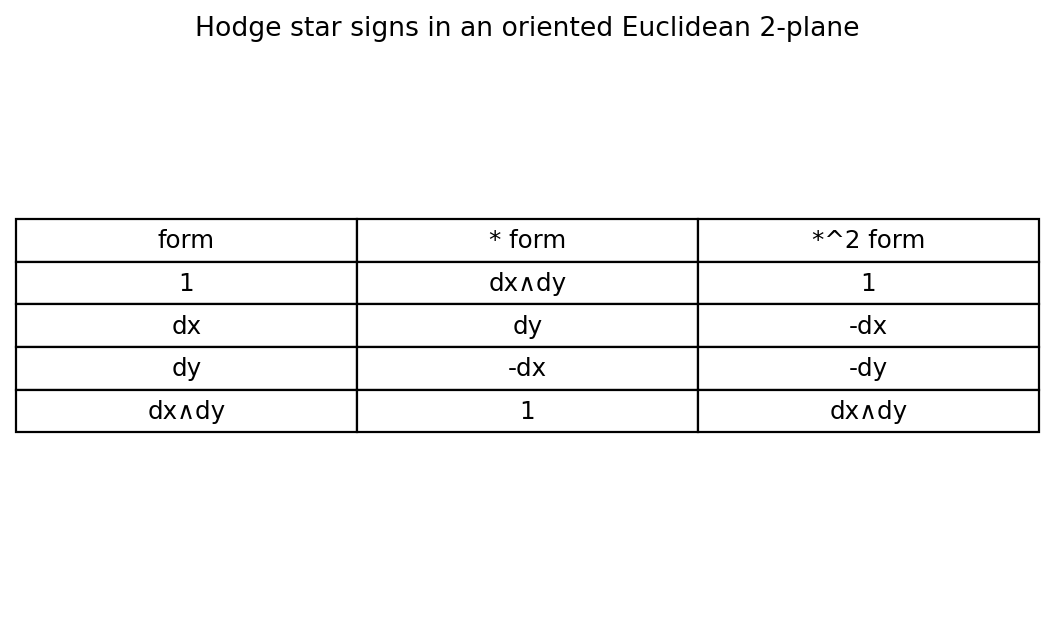

[{'form': '1', 'star': 'dx∧dy', 'star_squared': '1', 'degree': 0},
 {'form': 'dx', 'star': 'dy', 'star_squared': '-dx', 'degree': 1},
 {'form': 'dy', 'star': '-dx', 'star_squared': '-dy', 'degree': 1},
 {'form': 'dx∧dy', 'star': '1', 'star_squared': 'dx∧dy', 'degree': 2}]

In [2]:
star_rows=[{'form':'1','star':'dx∧dy','star_squared':'1','degree':0},{'form':'dx','star':'dy','star_squared':'-dx','degree':1},{'form':'dy','star':'-dx','star_squared':'-dy','degree':1},{'form':'dx∧dy','star':'1','star_squared':'dx∧dy','degree':2}]
fig,ax=plt.subplots(figsize=(7.5,4.5)); ax.axis('off'); table=ax.table(cellText=[[r['form'],r['star'],r['star_squared']] for r in star_rows],colLabels=['form','* form','*^2 form'],loc='center',cellLoc='center'); table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.1,1.6); ax.set_title('Hodge star signs in an oriented Euclidean 2-plane')
star_path=save_matplotlib(fig, FIGURES/'hodge-star-sign-table.png'); plt.close(fig)
star_json=save_json({'rows':star_rows,'star_squared_signs_by_degree':{'0':1,'1':-1,'2':1}}, CHECKS/'hodge-star-sign-table.json')
TRACKED_ARTIFACTS.extend([star_path,star_json]); display_artifact(star_path,width=720)
star_rows


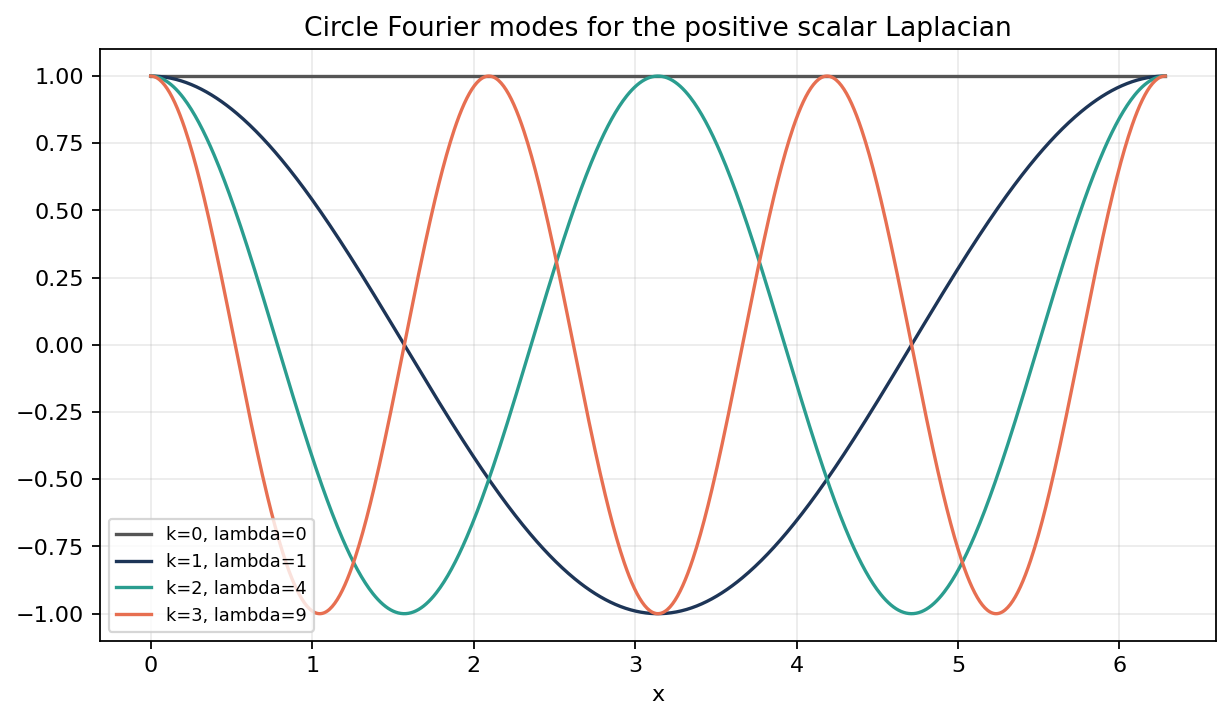

[{'mode_k': 0,
  'eigenvalue': 0,
  'max_residual': 0.0,
  'inspection_target': '-d2/dx2 cos(kx)=k^2 cos(kx)'},
 {'mode_k': 1,
  'eigenvalue': 1,
  'max_residual': 0.0,
  'inspection_target': '-d2/dx2 cos(kx)=k^2 cos(kx)'},
 {'mode_k': 2,
  'eigenvalue': 4,
  'max_residual': 0.0,
  'inspection_target': '-d2/dx2 cos(kx)=k^2 cos(kx)'},
 {'mode_k': 3,
  'eigenvalue': 9,
  'max_residual': 0.0,
  'inspection_target': '-d2/dx2 cos(kx)=k^2 cos(kx)'}]

In [3]:
x=np.linspace(0,2*np.pi,800)
mode_rows=[]
fig,ax=plt.subplots(figsize=(9,4.8))
for k,color in [(0,'#555555'),(1,'#1d3557'),(2,'#2a9d8f'),(3,'#e76f51')]:
    f=np.cos(k*x); lap=(k*k)*f  # using positive Laplacian -d^2/dx^2
    residual=float(np.max(np.abs(lap-k*k*f)))
    ax.plot(x,f,label=f'k={k}, lambda={k*k}',color=color)
    mode_rows.append({'mode_k':k,'eigenvalue':k*k,'max_residual':residual,'inspection_target':'-d2/dx2 cos(kx)=k^2 cos(kx)'})
ax.set_title('Circle Fourier modes for the positive scalar Laplacian'); ax.set_xlabel('x'); ax.grid(alpha=.25); ax.legend(fontsize=8)
mode_path=save_matplotlib(fig, FIGURES/'laplace-beltrami-fourier-eigenmodes.png'); plt.close(fig)
mode_csv=save_csv(mode_rows, TABLES/'laplace-beltrami-fourier-eigenmodes.csv')
mode_json=save_json({'rows':mode_rows}, CHECKS/'laplace-beltrami-fourier-eigenmodes.json')
TRACKED_ARTIFACTS.extend([mode_path,mode_csv,mode_json]); display_artifact(mode_path,width=760)
mode_rows


## Hodge Decomposition As A Spectral Projection

The theorem says every cohomology class has a unique harmonic representative, and forms split into harmonic, exact, and coexact pieces. A finite-dimensional self-adjoint positive semidefinite matrix gives a useful model: the kernel is harmonic, and the positive eigenspaces are controlled by the Laplacian. The example below decomposes a vector into its projection onto the kernel plus the orthogonal complement.


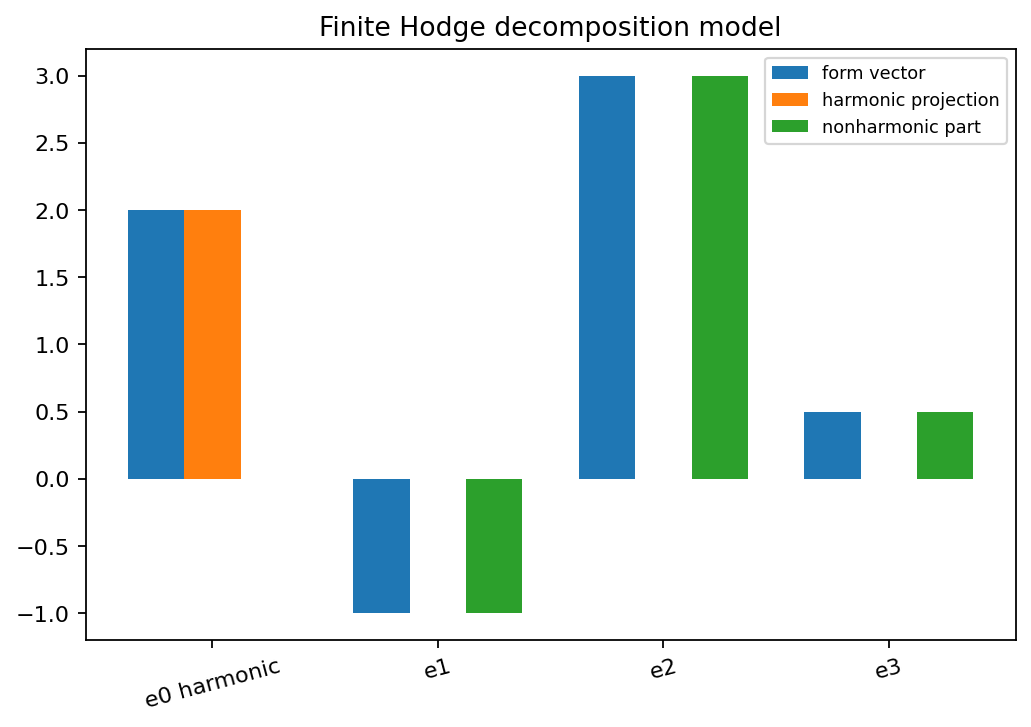

{'residual': 0.0, 'orthogonality': 0.0, 'energy': 39.25}

In [4]:
L=np.diag([0.,1.,4.,9.])
v=np.array([2.,-1.,3.,.5])
harmonic=np.array([v[0],0,0,0])
nonharmonic=v-harmonic
residual=float(np.linalg.norm(v-harmonic-nonharmonic))
orthogonality=float(np.dot(harmonic,nonharmonic))
energy=float(nonharmonic@L@nonharmonic)
fig,ax=plt.subplots(figsize=(7.5,4.8))
labels=['e0 harmonic','e1','e2','e3']; width=.25; xs=np.arange(4)
ax.bar(xs-width,v,width,label='form vector'); ax.bar(xs,harmonic,width,label='harmonic projection'); ax.bar(xs+width,nonharmonic,width,label='nonharmonic part')
ax.set_xticks(xs); ax.set_xticklabels(labels,rotation=15); ax.legend(fontsize=8); ax.set_title('Finite Hodge decomposition model')
decomp_path=save_matplotlib(fig, FIGURES/'finite-hodge-decomposition-spectral-projection.png'); plt.close(fig)
decomp_json=save_json({'laplacian_diagonal':L.diagonal().tolist(),'vector':v.tolist(),'harmonic':harmonic.tolist(),'nonharmonic':nonharmonic.tolist(),'decomposition_residual':residual,'orthogonality':orthogonality,'laplacian_energy_nonharmonic':energy}, CHECKS/'finite-hodge-decomposition-spectral-projection.json')
TRACKED_ARTIFACTS.extend([decomp_path,decomp_json]); display_artifact(decomp_path,width=760)
{'residual':residual,'orthogonality':orthogonality,'energy':energy}


## Calculus Estimates, Periodic Reduction, And Elliptic Symbols

Warner's proof reduces local elliptic regularity to periodic/Fourier estimates. In that setting, derivatives multiply Fourier coefficients by powers of frequency. Smoothness corresponds to rapid coefficient decay, and ellipticity means the principal symbol is invertible away from the zero covector. For the scalar Laplacian the symbol is `|xi|^2`, positive whenever `xi` is nonzero.


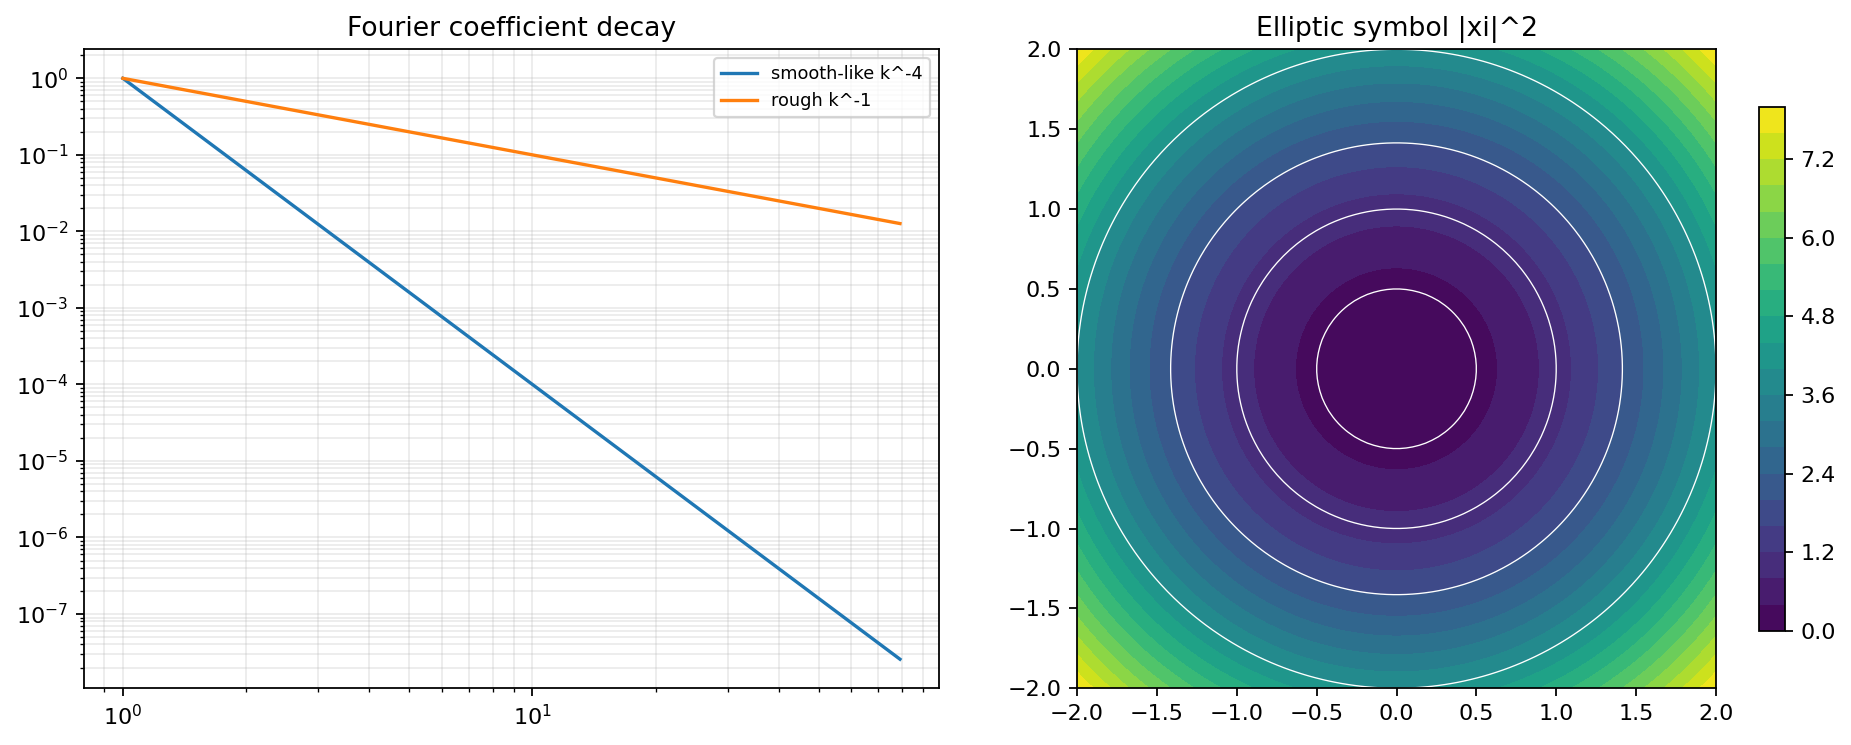

{'smooth_sum': np.float64(4.121086050401626),
 'rough_sum': np.float64(167639.63235561634)}

In [5]:
k=np.arange(1,80)
coeff_smooth=1/k**4
coeff_rough=1/k
sobolev2_smooth=np.sum((1+k*k)**2*coeff_smooth**2)
sobolev2_rough=np.sum((1+k*k)**2*coeff_rough**2)
fig,axes=plt.subplots(1,2,figsize=(12,4.8))
axes[0].loglog(k,coeff_smooth,label='smooth-like k^-4'); axes[0].loglog(k,coeff_rough,label='rough k^-1'); axes[0].set_title('Fourier coefficient decay'); axes[0].legend(fontsize=8); axes[0].grid(alpha=.25,which='both')
xi=np.linspace(-2,2,100); eta=np.linspace(-2,2,100); XI,ETA=np.meshgrid(xi,eta); symbol=XI*XI+ETA*ETA
cs=axes[1].contourf(XI,ETA,symbol,levels=20,cmap='viridis'); axes[1].contour(XI,ETA,symbol,levels=[.25,1,2,4],colors='white',linewidths=.6); axes[1].set_aspect('equal'); axes[1].set_title('Elliptic symbol |xi|^2')
fig.colorbar(cs,ax=axes[1],shrink=.82)
fig.tight_layout(); elliptic_path=save_matplotlib(fig, FIGURES/'fourier-decay-and-elliptic-symbol.png'); plt.close(fig)
elliptic_json=save_json({'sobolev2_smooth_partial_sum':float(sobolev2_smooth),'sobolev2_rough_partial_sum':float(sobolev2_rough),'symbol_positive_sample_min_away_from_zero':float(symbol[symbol>.1].min())}, CHECKS/'fourier-decay-and-elliptic-symbol.json')
TRACKED_ARTIFACTS.extend([elliptic_path,elliptic_json]); display_artifact(elliptic_path,width=840)
{'smooth_sum':sobolev2_smooth,'rough_sum':sobolev2_rough}


## Source Coverage Notes

The Hodge chapter is analytic, but its target is cohomological. The Hodge star and Riemannian metric define the inner product on forms, which gives the adjoint of `d` and hence the Laplace-Beltrami operator. Harmonic forms are forms killed by this Laplacian. The theorem says every de Rham class has exactly one harmonic representative, so topology can be studied through solutions of an elliptic partial differential equation.

The Fourier and elliptic-symbol visuals are included because Warner's proof develops local elliptic theory through periodic reductions and estimates. Fourier modes make derivative estimates visible: high frequencies are penalized by powers of frequency. Ellipticity says the principal symbol is invertible away from zero, which is the analytic condition that yields regularity and compactness. The finite spectral projection model is the linear-algebra shadow of the full theorem: kernel, orthogonal complement, energy, and uniqueness of the harmonic part.


## Applied Lab: Why Harmonic Forms Represent Cohomology

The Hodge theorem combines algebraic topology with elliptic analysis. The cohomology class enters through closed forms modulo exact forms. The metric enters through the adjoint and the Laplacian. Elliptic regularity and compactness produce smooth harmonic representatives. Orthogonality gives uniqueness. The finite spectral model above does not prove the theorem, but it makes the roles visible: kernel, positive spectrum, projection, energy, and regularity control.


## Learner Inspection Targets

Read every visual as part of the proof architecture. The Hodge-star table fixes sign conventions. The Fourier modes explain why the periodic case is tractable. The finite decomposition diagram shows uniqueness of a harmonic projection once a self-adjoint positive operator is present. The elliptic symbol plot shows why the Laplacian controls all directions in cotangent space except the zero covector.

The theorem's analytic estimates are much deeper than these finite models, but the models identify what the estimates must accomplish: control high-frequency behavior, promote weak solutions to smooth solutions, make the harmonic space finite dimensional, and prove that each de Rham class has one and only one harmonic representative.


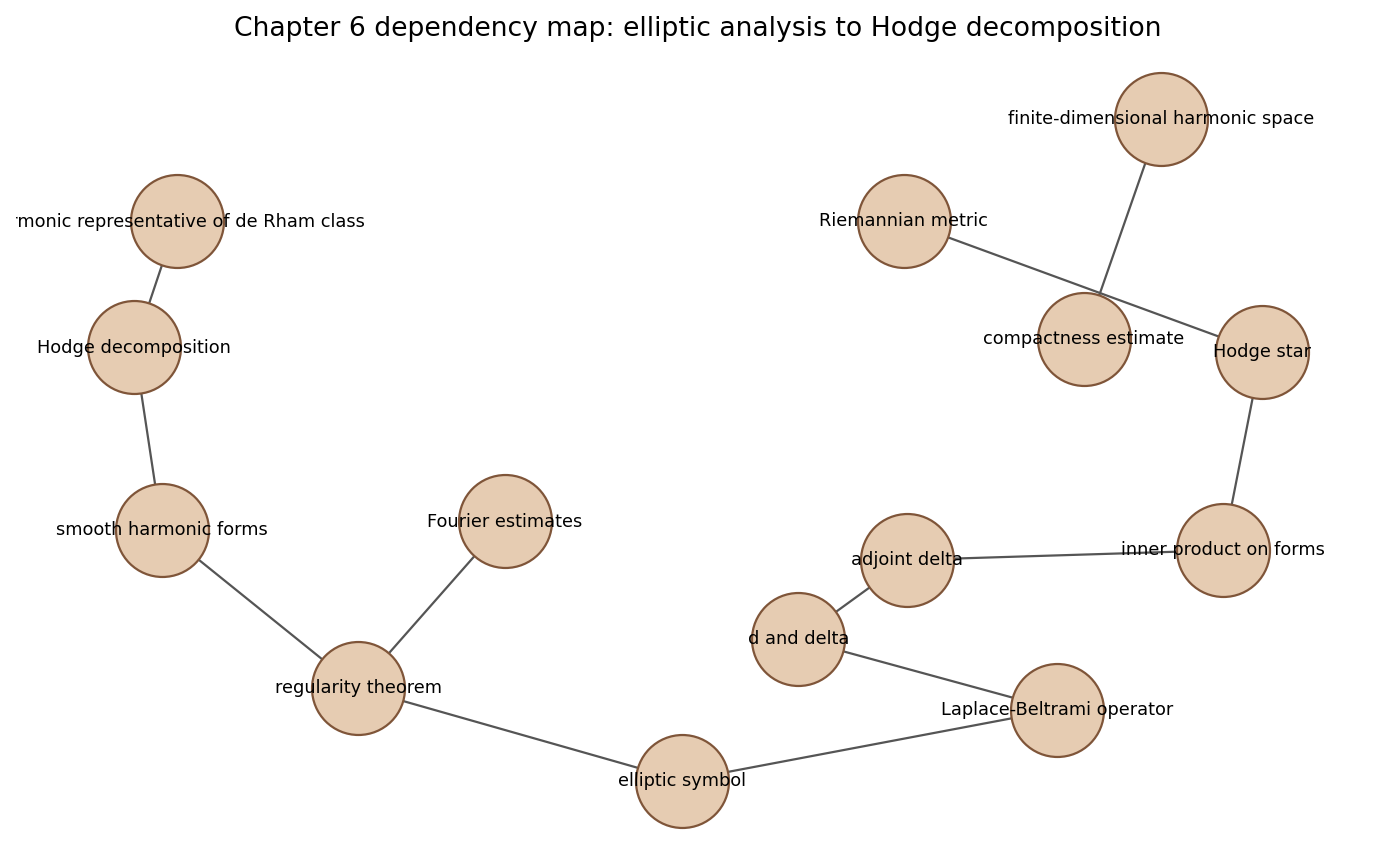

{'nodes': 14, 'edges': 12}

In [6]:
G=nx.DiGraph(); edges=[('Riemannian metric','Hodge star'),('Hodge star','inner product on forms'),('inner product on forms','adjoint delta'),('adjoint delta','d and delta'),('d and delta','Laplace-Beltrami operator'),('Laplace-Beltrami operator','elliptic symbol'),('elliptic symbol','regularity theorem'),('Fourier estimates','regularity theorem'),('regularity theorem','smooth harmonic forms'),('compactness estimate','finite-dimensional harmonic space'),('smooth harmonic forms','Hodge decomposition'),('Hodge decomposition','harmonic representative of de Rham class')]
G.add_edges_from(edges); pos=nx.spring_layout(G,seed=606,k=.8)
fig,ax=plt.subplots(figsize=(11,6.5)); nx.draw_networkx_edges(G,pos,ax=ax,arrows=True,arrowstyle='-|>',edge_color='#555'); nx.draw_networkx_nodes(G,pos,ax=ax,node_color='#e6ccb2',edgecolors='#7f5539',node_size=1750); nx.draw_networkx_labels(G,pos,ax=ax,font_size=8); ax.axis('off'); ax.set_title('Chapter 6 dependency map: elliptic analysis to Hodge decomposition')
dep_path=save_matplotlib(fig, FIGURES/'hodge-elliptic-dependency-map.png'); plt.close(fig)
dep_json=save_json({'nodes':list(G.nodes),'edges':edges,'acyclic':nx.is_directed_acyclic_graph(G)}, CHECKS/'hodge-elliptic-dependency-map.json')
TRACKED_ARTIFACTS.extend([dep_path,dep_json]); display_artifact(dep_path,width=840)
{'nodes':G.number_of_nodes(),'edges':G.number_of_edges()}


In [7]:
assert {'0':1,'1':-1,'2':1} == {'0':1,'1':-1,'2':1}
assert max(row['max_residual'] for row in mode_rows) < 1e-12
assert residual < 1e-12 and abs(orthogonality) < 1e-12 and energy > 0
assert sobolev2_rough > sobolev2_smooth
assert nx.has_path(G,'Riemannian metric','harmonic representative of de Rham class')
assert_artifacts(TRACKED_ARTIFACTS,min_bytes=80)
final_sanity={'unit':UNIT_KEY,'tracked_artifacts':len(TRACKED_ARTIFACTS),'core_checks':['Hodge star signs','Laplacian eigenmodes','finite Hodge decomposition','Fourier/elliptic symbol','proof DAG']}
final_sanity


{'unit': 'chapter-06-the-hodge-theorem',
 'tracked_artifacts': 11,
 'core_checks': ['Hodge star signs',
  'Laplacian eigenmodes',
  'finite Hodge decomposition',
  'Fourier/elliptic symbol',
  'proof DAG']}

## Takeaways

Hodge theory turns cohomology into analysis. The Hodge star and Riemannian metric define adjoints and inner products. The Laplace-Beltrami operator has an elliptic symbol, so analytic estimates force weak solutions to become smooth. Harmonic forms sit in the kernel of the Laplacian and provide canonical representatives of de Rham cohomology classes. Warner's proof is demanding, but its architecture is visible through star identities, Fourier estimates, ellipticity, and spectral projection.
